# DC Motor, No Load Test, data processing

In [25]:
# Packages
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import seaborn as sns
import os

# No load Test
## Rotor speed and position
First we need to load in the measurements.

In [26]:
# Folder name
CSV_folder_name = "CSV_files"
figure_folder_name = "figures"

# Load data from CSV file
file_name = "motor2.csv" # CSV name
file_path = os.path.join(CSV_folder_name, file_name) # Generate file path
raw_df = pd.read_csv(file_path) # Read CSV file.

# Option to save data and figures ( True = Save data and figures, False = Don't save data and figures )
SAVE = False

Then let's plot the data.

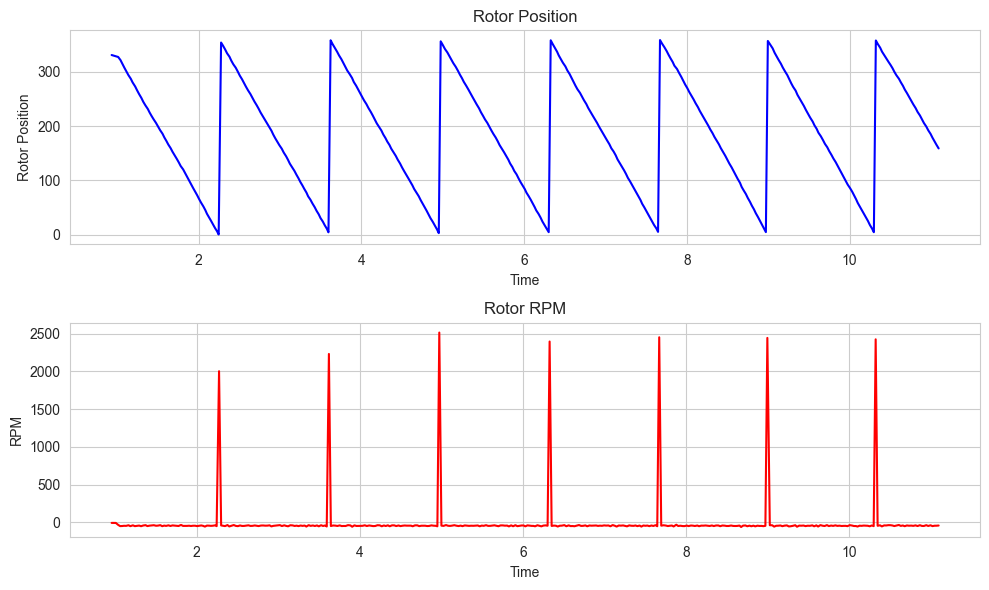

In [27]:
# Select example sample from data set
sample = 3
data_type = 0 # (Angle = 0, V_bus = 1, V_shunt = 2, current = 3)

# Create new dataframe for rotor data, containing rotor position and time
rotor_data = pd.concat([raw_df.iloc[:, (5*sample + data_type)], raw_df.iloc[:, (5*sample + 4)]], axis=1)
rotor_data.columns = ['rotor_position', 'Time']

# Calculate motor RPM from raw data
rotor_data['RPM'] = rotor_data['rotor_position'].diff() / rotor_data['Time'].diff() * (60 / 360)

# Plotting
## Create Figure
plt.figure(figsize=(10, 6))

## Rotor position plot
plt.subplot(2, 1, 1)
plt.plot(rotor_data['Time'], rotor_data['rotor_position'], color='blue')
plt.title("Rotor Position")
plt.xlabel('Time')
plt.ylabel('Rotor Position')

## Motor RPM plot
plt.subplot(2, 1, 2)
plt.plot(rotor_data['Time'][1:], rotor_data['RPM'][1:], color='red')  # Omit first row due to NaN in RPM calculation
plt.title("Rotor RPM")
plt.xlabel('Time')
plt.ylabel('RPM')

# Save figure
file_name = "raw_rotor_pos_and_RPM.pdf" # Plot name
file_path = os.path.join(figure_folder_name, file_name) # Generate file path
if SAVE:
    plt.savefig(file_path, format='pdf')

## Show plot
plt.tight_layout()
plt.show()

From the plot above, we see we counter two issues with the data:
- The rotor position goes from 0-359 degrees, resetting every 360 degrees.
- Every time the rotor position resets, the estimated velocity goes to the moon.
- The motor spins counter clock wise (CCW).

In order to improve the angular velocity estimate, we can do two things:
- Invert the rotor position data, from 359-0 to 0-359 degrees.
- Remove all negative values from the angular velocity estimate, since we know the motor spins in one direction at a constant speed.

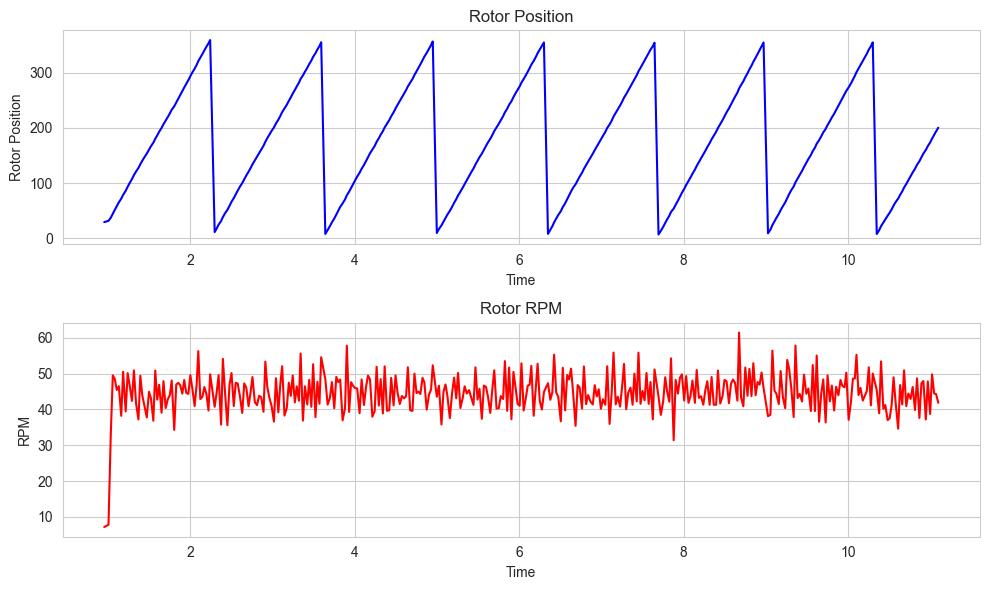

In [28]:
# Invert data
rotor_data['rotor_position'] = 359 - rotor_data['rotor_position'] 

# Calculate motor RPM from raw data
rotor_data['RPM'] = rotor_data['rotor_position'].diff() / rotor_data['Time'].diff() * (60 / 360)

# Remove negative values
rotor_data = rotor_data[rotor_data['RPM'] >= 0]



# Plotting
## Create Figure
plt.figure(figsize=(10, 6))

## Rotor position plot
plt.subplot(2, 1, 1)
plt.plot(rotor_data['Time'], rotor_data['rotor_position'], color='blue')
plt.title("Rotor Position")
plt.xlabel('Time')
plt.ylabel('Rotor Position')

## Motor RPM plot
plt.subplot(2, 1, 2)
plt.plot(rotor_data['Time'], rotor_data['RPM'], color='red') 
plt.title("Rotor RPM")
plt.xlabel('Time')
plt.ylabel('RPM')
plt.tight_layout()

# Save figure
file_name = "corrected_rotor_pos_and_RPM.pdf" # Plot name
file_path = os.path.join(figure_folder_name, file_name) # Generate file path
if SAVE:
    plt.savefig(file_path, format='pdf')

## Show plot
plt.show()

Now the data is looking a lot more reasonable. But we can still we that the speed data is containing some artifacts. We can filter this out with outlier detection, and interpolate the missing values. 

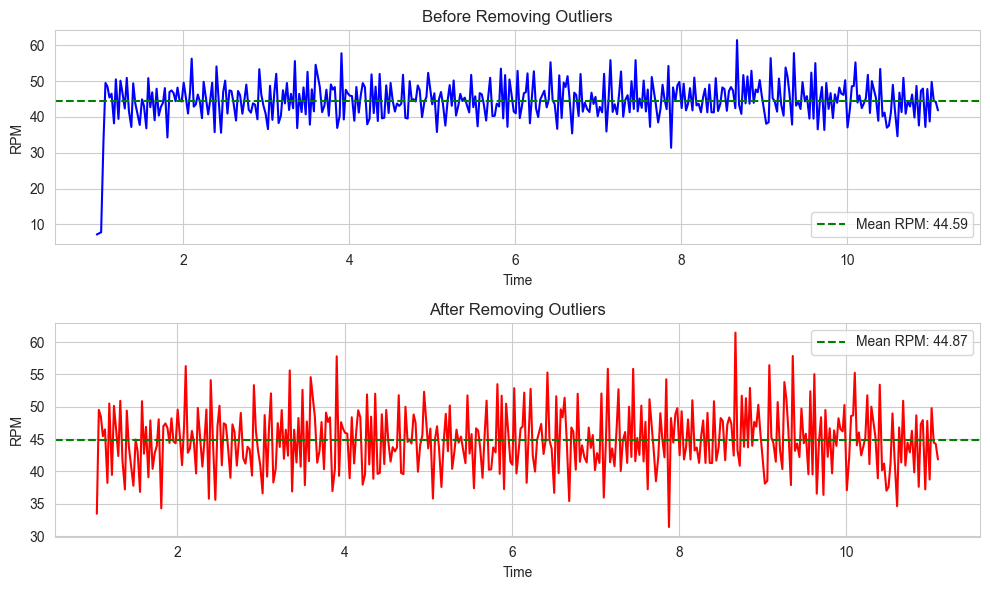

The mean RPM before outlier removal is: 44.5858 RPM
The mean RPM after outlier removal is: 44.8719 RPM
This amounts to a difference of: 0.2861 RPM


In [29]:
# Calculate z-scores for each value in the 'RPM' column
z_scores = stats.zscore(rotor_data['RPM'])

# Define a threshold for identifying outliers (e.g., 3 standard deviations from the mean)
threshold = 3

# Find the indices of outliers
outlier_indices = np.abs(z_scores) > threshold

# Remove outliers from the DataFrame
cleaned_rotor_data = rotor_data[~outlier_indices]


# Calculate mean RPM before removing outliers
mean_rpm_before = rotor_data['RPM'].mean()

# Calculate mean RPM after removing outliers
mean_rpm_after = cleaned_rotor_data['RPM'].mean()

# Plot 'RPM' column before removing outliers
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(rotor_data['Time'], rotor_data['RPM'], color='blue')
plt.axhline(y=mean_rpm_before, color='green', linestyle='--', label=f'Mean RPM: {mean_rpm_before:.2f}')
plt.title('Before Removing Outliers')
plt.xlabel('Time')
plt.ylabel('RPM')
plt.legend()

# Plot 'RPM' column after removing outliers
plt.subplot(2, 1, 2)
plt.plot(cleaned_rotor_data['Time'], cleaned_rotor_data['RPM'], color='red')
plt.axhline(y=mean_rpm_after, color='green', linestyle='--', label=f'Mean RPM: {mean_rpm_after:.2f}')
plt.title('After Removing Outliers')
plt.xlabel('Time')
plt.ylabel('RPM')
plt.legend()
plt.tight_layout()

# Save figure
file_name = "filtered_and_unfiltered_RPM.pdf" # Plot name
file_path = os.path.join(figure_folder_name, file_name) # Generate file path
if SAVE:
    plt.savefig(file_path, format='pdf')

# Show plot
plt.show()

# Lastly, update RPM in rotor_data
rotor_data['RPM'] = cleaned_rotor_data['RPM']

# Print mean RPM before and after outlier removal
print(f"The mean RPM before outlier removal is: {mean_rpm_before:.4f} RPM")
print(f"The mean RPM after outlier removal is: {mean_rpm_after:.4f} RPM")
print(f"This amounts to a difference of: {abs(mean_rpm_before - mean_rpm_after):.4f} RPM")



With this data filtering, we will assume that we have a decent data set, and can apply this to the entirety of the data.

In [30]:
RPM_df = pd.DataFrame()

# Assuming df is your dataframe
num_columns = len(raw_df.columns)

# Iterating through every fifth column
for sample in range(0, num_columns, 5):
    # Create new dataframe for rotor data, containing rotor position and time
    rotor_data = pd.concat([raw_df.iloc[:, (sample)], raw_df.iloc[:, (sample + 4)]], axis=1)
    rotor_data.columns = ['rotor_position', 'Time']

    ## Invert data
    rotor_data['rotor_position'] = 359 - rotor_data['rotor_position'] 

    # Calculate motor RPM from raw data
    rotor_data['RPM'] = rotor_data['rotor_position'].diff() / rotor_data['Time'].diff() * (60 / 360)

    # Remove negative values
    rotor_data = rotor_data[rotor_data['RPM'] >= 0]

    # Calculate z-scores for each value in the 'RPM' column
    z_scores = stats.zscore(rotor_data['RPM'])

    # Define a threshold for identifying outliers (e.g., 3 standard deviations from the mean)
    threshold = 3

    # Find the indices of outliers
    outlier_indices = np.abs(z_scores) > threshold

    # Remove outliers from the DataFrame
    cleaned_rotor_data = rotor_data[~outlier_indices]

    # Add to RPM dataframe
    RPM_df[f'{(sample/5) * 0.5}V'] = cleaned_rotor_data['RPM']  


# Final data clean up
# Replace "inf" values with NaN
RPM_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Replace NaN values in each column with interpolation
RPM_df = RPM_df.interpolate()

# Remove first rows with NaN values.
nan_index = RPM_df.index[RPM_df.isnull().any(axis=1)][0]
RPM_df = RPM_df.iloc[nan_index + 2:]

# Remove non-zero values from first column, we know the speed of the motor was zero.
RPM_df.iloc[:, 0] = 0

# Reset index to start from zero
RPM_df = RPM_df.reset_index(drop=True)

# Display Table
rounded_df = RPM_df.round(1)
rounded_df

c:\Users\Eirik\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\_methods.py:236: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
c:\Users\Eirik\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\_methods.py:236: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


,0.0V,0.5V,1.0V,1.5V,2.0V,2.5V,3.0V,3.5V,4.0V,4.5V,...,12.5V,13.0V,13.5V,14.0V,14.5V,15.0V,15.5V,16.0V,16.5V,17.0V
0,0.0,0.0,0.0,49.5,81.7,98.8,118.2,193.8,203.9,286.2,...,893.9,946.9,931.2,786.4,1044.5,1065.8,916.5,1258.9,975.2,1115.5
1,0.0,0.0,0.0,48.5,85.0,125.3,148.8,154.0,203.4,252.6,...,958.9,931.9,835.8,865.3,950.2,1037.1,1112.6,947.4,1056.4,1199.4
2,0.0,0.0,0.0,45.4,71.2,105.4,137.4,172.9,268.4,231.2,...,652.9,688.8,782.5,857.0,855.9,1024.1,1087.1,942.9,1137.6,1199.8
3,0.0,0.0,0.0,38.2,70.2,107.9,136.2,194.4,230.4,253.1,...,710.0,792.3,768.1,848.7,846.2,1011.0,1061.7,938.4,983.4,1200.1
4,0.0,0.0,0.0,50.5,88.9,112.7,120.6,157.8,202.8,253.1,...,877.9,920.0,1056.4,911.1,836.5,997.9,1036.2,933.9,982.4,1200.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,0.0,0.0,0.0,47.9,98.1,97.9,152.9,150.3,204.6,244.6,...,818.3,698.9,745.3,1009.6,864.3,963.8,1121.6,1126.4,971.3,1201.3
344,0.0,0.0,0.0,37.2,71.4,103.9,178.5,158.1,236.5,231.7,...,874.1,845.6,790.4,1060.4,854.3,886.2,1106.9,1132.9,971.9,1192.7
345,0.0,0.0,0.0,47.8,73.2,133.0,162.2,165.9,195.7,218.8,...,687.1,817.0,835.6,1097.9,1103.0,906.5,1092.1,1121.6,972.4,1133.0
346,0.0,0.0,0.0,49.8,76.1,129.0,145.8,168.3,216.8,246.0,...,765.6,788.5,830.6,1135.4,933.5,1064.8,1016.9,1110.4,1016.2,1073.3


Regression line:  y(x) = 0.905 + 0.0145x.
Regression line:  V(RPM) = 0.905V + 0.0145*RPM.


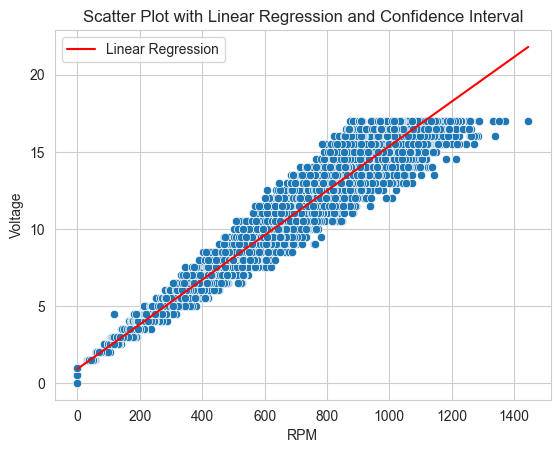

In [31]:
# Initialize empty numpy arrays for x and y
x = np.array([])
y = np.array([])

n = 0
# Loop through each column in the DataFrame
for column in RPM_df.columns:
    # Add values from the column to y array
    x = np.append(x, RPM_df[column].values)
    
    # Add an array of 2s to x array (assuming the same length as y)
    y = np.append(y, np.full_like(RPM_df[column].values, n*0.5))
    n += 1


# Perform linear regression
slope, intercept, _, _, stderr = stats.linregress(x, y)
print("Regression line:  y(x) = {:.3f} + {:.4f}x.".format(intercept, abs(slope)))
print("Regression line:  V(RPM) = {:.3f}V + {:.4f}*RPM.".format(intercept, abs(slope)))
# Calculate confidence interval
conf_interval = 1.96 * stderr  # 95% confidence interval

# Create scatter plot of x and y values with seaborn
sns.scatterplot(x=x, y=y)

# Plot the regression line with confidence interval using seaborn
sns.lineplot(x=x, y=slope * x + intercept, color='red', label='Linear Regression', err_style='band')

# Add labels and title
plt.xlabel('RPM')
plt.ylabel('Voltage')
plt.title('Scatter Plot with Linear Regression and Confidence Interval')
plt.legend()  # Show legend

# Save figure
file_name = "motor_constant_lin_reg.pdf" # Plot name
file_path = os.path.join(figure_folder_name, file_name) # Generate file path
if SAVE:
    plt.savefig(file_path, format='pdf')

# Show the plot
plt.show()



While we now have a linear equation for motor speed vs voltage, we still lack part of the equation:
$$V = R \cdot I + k_e \cdot \omega$$

In our regression line, $R \cdot I$ is constant, while it actuality, it varies by current. We can fix this by including the current measurement data, and offsetting the voltages by the voltage drop caused by the internal resistance in the motor. 

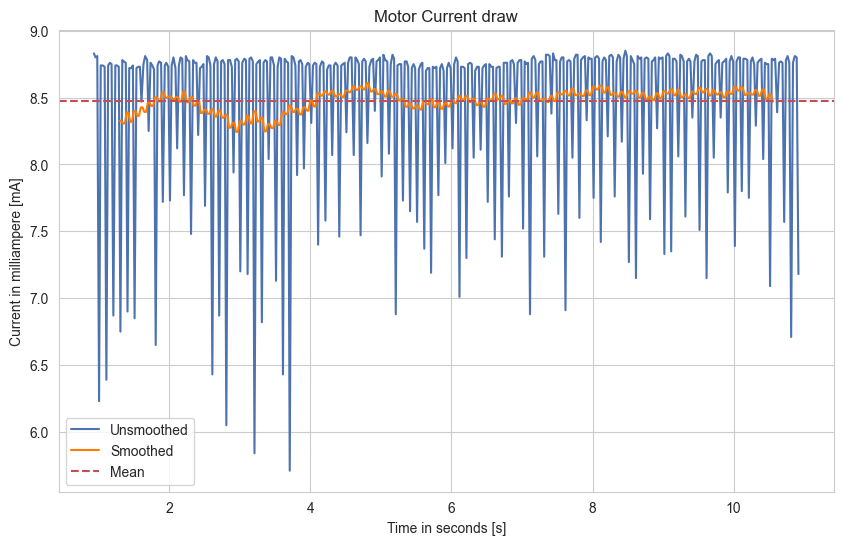

Mean Current: 0.00846735


In [32]:
# Select example sample from data set
sample = 2
data_type = 2 # (Angle = 0, V_bus = 1, V_shunt = 2, current = 3)

# Create new dataframe for rotor data, containing rotor position and time
current_data = pd.concat([raw_df.iloc[:, (5*sample + data_type)], raw_df.iloc[:, (5*sample + 4)]], axis=1)
current_data.columns = ['Current', 'Time']

# Apply the moving average using rolling method
window_size = 30
smoothed_df = current_data.rolling(window=window_size).mean()

# Drop rows with NaN values introduced by rolling method
smoothed_df.dropna(inplace=True)


# Plotting
# Set the style
sns.set_style("whitegrid")

# Accessing similar colors in seaborn's color palette
royal_blue = sns.color_palette('deep')[0]  # Similar to royal blue
bright_green = sns.color_palette('bright')[1]  # Higher contrast green color
coral_pink = sns.color_palette('deep')[3]  # Similar to coral pink

# Create Figure
plt.figure(figsize=(10, 6))

# Plot unsmoothed data with royal blue color
plt.plot(current_data['Time'], current_data['Current'], color=royal_blue, label='Unsmoothed')

# Plot smoothed data with brighter green color
plt.plot(smoothed_df['Time'], smoothed_df['Current'], color=bright_green, label='Smoothed')

# Plot horizontal line for the mean value with coral pink color
plt.axhline(y=smoothed_df['Current'].mean(), color=coral_pink, linestyle='--', label='Mean')

# Add labels and title
plt.xlabel('Time in seconds [s]')
plt.ylabel('Current in milliampere [mA]')
plt.title('Motor Current draw')

# Add legend
plt.legend()

# Save figure
file_name = "mean_current_draw.pdf" # Plot name
file_path = os.path.join(figure_folder_name, file_name) # Generate file path
if SAVE:
    plt.savefig(file_path, format='pdf')

# Show the plot
plt.show()

# Print the mean voltage
print("Mean Current:", (current_data['Current'].mean()/1000))

In [33]:
# Select example sample from data set
sample = 2
data_type = 2 # (Angle = 0, V_bus = 1, V_shunt = 2, current = 3)

# Create new dataframe for rotor data, containing rotor position and time
voltage_data = pd.concat([raw_df.iloc[:, (5*sample + 1)], raw_df.iloc[:, (5*sample + 2)], raw_df.iloc[:, (5*sample + 3)], raw_df.iloc[:, (5*sample + 4)]], axis=1)
voltage_data.columns = ['V_bus', 'V_shunt', "Current", "Time"]

# Change V_shunt from mV to V and Current from mA to A
voltage_data['V_shunt'] = voltage_data['V_shunt'] / 1000
voltage_data["Current"] = voltage_data["Current"] / 1000

# Calculate armature resistance.
voltage_data["Armature Resistance"] = ( 0.5 - voltage_data['V_shunt'] ) / voltage_data['Current']
armature_resistance = voltage_data['Armature Resistance'].mean()

# Print estimated resitance
print("Estimated Armature Resistance = {:.2f}Ω.".format(armature_resistance))

Estimated Armature Resistance = 5.96Ω.


With this new resistance value, we can calculate the back-EMF voltages for each RPM for the motor.

In [34]:
# Create an empty DataFrame to store voltage data
voltage_df = pd.DataFrame()

# Find number of columns in raw_df
num_columns = len(raw_df.columns)

# Iterating through every fifth column
for sample in range(0, num_columns, 5):
    # Import data from raw_df and add 'Time', 'current', and 'V_shunt' columns
    temp_df = pd.DataFrame({
        'Time': raw_df.iloc[:, (sample + 4)],
        'current': raw_df.iloc[:, (sample + 3)],
        'V_shunt': raw_df.iloc[:, (sample + 2)]
    })
    
    # Add bus voltage column
    temp_df['V_Bus'] = 0.5 * (sample / 5) * np.ones(len(raw_df))
    
    # Concatenate temp_df to voltage_df
    voltage_df = pd.concat([voltage_df, temp_df], ignore_index=True)


# Calculate IR
voltage_df['V_IR'] = (voltage_df['current'] / 1000) * armature_resistance # Convert from mA to A then calculate IR.

# Calculate back EMF (BEMF)(E)
voltage_df['V_E'] = voltage_df['V_Bus'] - voltage_df['V_IR'] - (voltage_df['V_shunt'] / 1000)

# Display voltage_df
voltage_df

,Time,current,V_shunt,V_Bus,V_IR,V_E
0,0.929336,0.2,0.03,0.0,0.001193,-0.001223
1,0.953354,0.2,0.02,0.0,0.001193,-0.001213
2,0.978255,-0.2,0.07,0.0,-0.001193,0.001123
3,1.001360,0.2,0.02,0.0,0.001193,-0.001213
4,1.025383,0.2,0.02,0.0,0.001193,-0.001213
...,...,...,...,...,...,...
13995,11.557393,182.5,17.80,17.0,1.088253,15.893947
13996,11.585408,183.5,15.54,17.0,1.094216,15.890244
13997,11.614021,107.0,17.92,17.0,0.638044,16.344036
13998,11.642498,178.7,17.38,17.0,1.065594,15.917026


With these new voltage values for back EMF $E$, we can redo the linear regression

In [35]:
# Create an empty DataFrame for motor constant
K_motor_df = pd.DataFrame()

# Iterating through every fifth column
for sample in range(0, len(raw_df.columns), 5):
    # Import data
    ## Create temporary dataframe for motor data
    temp_df = pd.concat([raw_df.iloc[:, (sample + 4)], raw_df.iloc[:, sample], raw_df.iloc[:, (sample + 3)], raw_df.iloc[:, (sample + 2)]], axis=1)
    temp_df.columns = ['Time', 'rotor_position', 'current', 'V_shunt']

    ## Rescale data
    temp_df['rotor_position'] = 359 - temp_df['rotor_position'] # Reverse rotation
    temp_df['current'] /= 1000  # Convert from mA to A
    temp_df['V_shunt'] /= 1000  # Convert from mV to V

    # Calculate motor RPM from raw data
    temp_df['RPM'] = temp_df['rotor_position'].diff() / temp_df['Time'].diff() 
    temp_df['RPM'] *= (60 / 360)  # Convert from deg/s to RPM


    # Calculate BEMF [E]
    ## Add bus voltage 
    temp_df['V_Bus'] = 0.5 * (sample / 5) * np.ones(len(raw_df))

    ## Calculate IR
    temp_df['V_IR'] = (temp_df['current']) * armature_resistance # Calculate IR.

    ## Calculate back EMF (BEMF)(E)
    temp_df['V_E'] = temp_df['V_Bus'] - temp_df['V_IR'] - (temp_df['V_shunt'])


    # Clean up data
    ## Remove negative values
    temp_df = temp_df[temp_df['RPM'] >= 0]

    ## Calculate z-scores for each value in the 'RPM' column
    z_scores = stats.zscore(temp_df['RPM'])

    ## Define a threshold for identifying outliers (e.g., 3 standard deviations from the mean)
    threshold = 3

    ## Find the indices of outliers
    outlier_indices = np.abs(z_scores) > threshold

    ## Remove outliers from the DataFrame
    temp_df = temp_df[~outlier_indices]

    # Append temp_df to K_motor_df
    K_motor_df = pd.concat([K_motor_df, temp_df], ignore_index=True)


# Final data clean up
## Replace "inf" values with NaN
K_motor_df.replace([np.inf, -np.inf], np.nan, inplace=True)

## Replace NaN values in each column with interpolation
K_motor_df = K_motor_df.interpolate()

## Check if there are any NaN values in the DataFrame before accessing index
if K_motor_df.isnull().any(axis=1).any():
    nan_index = K_motor_df.index[K_motor_df.isnull().any(axis=1)][0]
    K_motor_df = K_motor_df.iloc[nan_index + 2:]

## Remove non-zero values from first column, we know the speed of the motor was zero.
K_motor_df.iloc[:, 0] = 0

## Reset index to start from zero
K_motor_df = K_motor_df.reset_index(drop=True)

# Save data
if SAVE:
    file_name = "K_motor.csv" # CSV name
    file_path = os.path.join(CSV_folder_name, file_name) # Generate file path
    K_motor_df.to_csv(file_path, index=False) # Save df

# Display Table
rounded_df = K_motor_df.round(1)
rounded_df

c:\Users\Eirik\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\_methods.py:236: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
c:\Users\Eirik\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\_methods.py:236: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


,Time,rotor_position,current,V_shunt,RPM,V_Bus,V_IR,V_E
0,0.0,212.4,0.0,0.0,0.0,0.0,0.0,-0.0
1,0.0,212.5,-0.0,0.0,0.6,0.0,-0.0,0.0
2,0.0,212.4,0.0,0.0,0.0,0.0,0.0,-0.0
3,0.0,212.4,0.0,0.0,0.0,0.0,0.0,-0.0
4,0.0,212.4,0.0,0.0,0.0,0.0,0.0,-0.0
...,...,...,...,...,...,...,...,...
10611,0.0,321.5,0.2,0.0,1209.9,17.0,0.9,16.1
10612,0.0,305.1,0.2,0.0,1192.7,17.0,1.1,15.9
10613,0.0,294.8,0.2,0.0,1206.9,17.0,1.1,15.9
10614,0.0,278.6,0.1,0.0,1013.7,17.0,0.6,16.3


Regression line:  y(x) = 0.418 + 0.0140x.
Regression line:  V(RPM) = 0.418V + 0.0140*RPM.
Motor Constant: (13.99mV / RPM ).


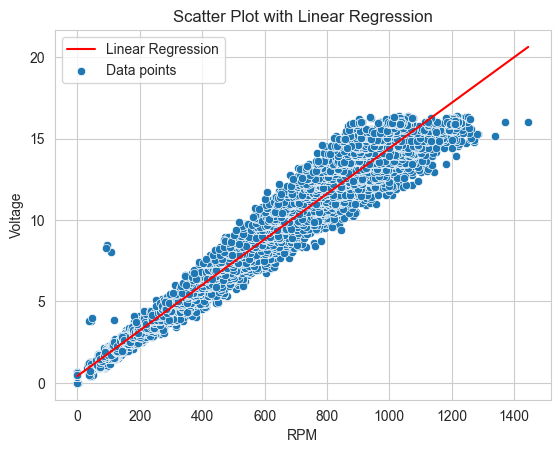

In [36]:
# Extract x and y values
x = K_motor_df['RPM'].values
y = K_motor_df['V_E'].values 

# Perform linear regression
slope, intercept, _, _, stderr = stats.linregress(x, y)
print("Regression line:  y(x) = {:.3f} + {:.4f}x.".format(intercept, abs(slope)))
print("Regression line:  V(RPM) = {:.3f}V + {:.4f}*RPM.".format(intercept, abs(slope)))
print("Motor Constant: ({:.2f}mV / RPM ).".format(slope*1000))

# Calculate estimated values
K_motor_df['V_E_hat'] = slope * x + intercept

# Save data
if SAVE:
    file_name = "K_motor.csv" # CSV name
    file_path = os.path.join(CSV_folder_name, file_name) # Generate file path
    K_motor_df.to_csv(file_path, index=False) # Save df


# Plot the regression line with confidence interval using seaborn
sns.lineplot(x=x, y=( K_motor_df['V_E_hat'].values ), color='red', label='Linear Regression')

# Create scatter plot of x and y values with seaborn
sns.scatterplot(x=x, y=y, label='Data points')

# Add labels and title
plt.xlabel('RPM')
plt.ylabel('Voltage')
plt.title('Scatter Plot with Linear Regression')
plt.legend()  # Show legend

# Save figure
file_name = "motor_constant_w_o_IR.pdf" # Plot name
file_path = os.path.join(figure_folder_name, file_name) # Generate file path
if SAVE:
    plt.savefig(file_path, format='pdf')

# Show the plot
plt.show()